 # Bitcoin Price Prediction


La variable objetivo es el **retorno logarítmico del precio Close**. Esta transformación garantiza estacionariedad en la serie, como se demostró en el EDA mediante el test ADF.

## Setup y carga de datos

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# Pipeline y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Optimización
from itertools import product
from scipy.stats import randint, uniform
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from deap import base, creator, tools, algorithms
import random

# Split temporal
from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# Tests estadísticos
from statsmodels.tsa.stattools import bds
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# LIME
import lime
import lime.lime_tabular
from IPython.display import display


# Directorio de salida para artefactos
os.makedirs('outputs', exist_ok=True)

print('Librerías cargadas correctamente')


Librerías cargadas correctamente


In [39]:
# Carga y preprocesamiento de datos 
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][["Open","High","Low","Close","Volume"]].resample('15min').mean()
df = df.dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')

Datos cargados: 250,581 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00


El dataset queda con 250.581 observaciones y en el periodo del 2019-01-01 hasta el 2026-02-24

## Construcción de features

La variable objetivo es el **retorno logarítmico del Close**. Como el EDA mostró que 7 lags captura la memoria relevante de la serie (menor RMSE y residuos independientes según BDS), se usan **7 lags** como features de entrada.

Serie de retornos: 250,580 observaciones
Media: 0.000011 | Std: 0.002869


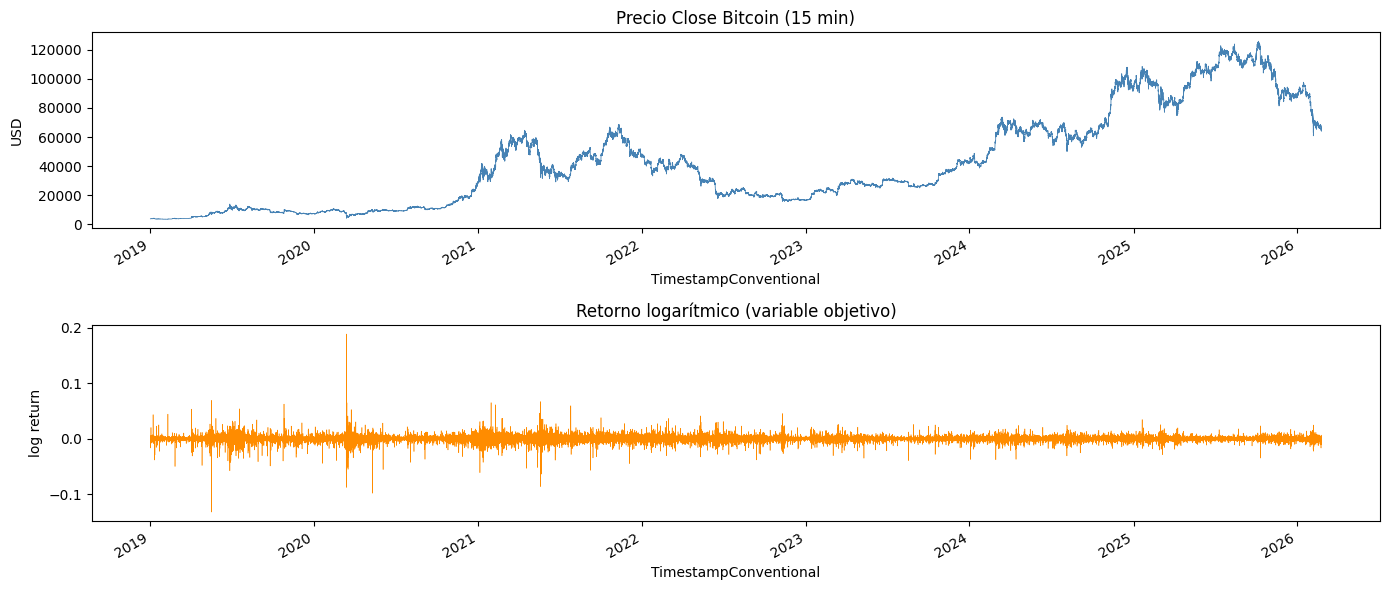

In [40]:
# Retorno logarítmico
log_return = np.log(df['Close']).diff().dropna()

# Parámetros del problema
N_LAGS     = 7   # inputs: 7 pasos previos
N_STEPS    = 1   # output: predecir 1 paso adelante
N_JUMP     = 1   # salto en cada muestra
RANDOM_SEED = 42

print(f'Serie de retornos: {len(log_return):,} observaciones')
print(f'Media: {log_return.mean():.6f} | Std: {log_return.std():.6f}')

# Visualización rápida
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
df['Close'].plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].set_title('Precio Close Bitcoin (15 min)')
axes[0].set_ylabel('USD')

log_return.plot(ax=axes[1], color='darkorange', linewidth=0.4)
axes[1].set_title('Retorno logarítmico (variable objetivo)')
axes[1].set_ylabel('log return')

plt.tight_layout()
plt.show()

La media de 0.000011 la cual es practicamente cero confirman que el Bitcoin no sube ni baja de forma consistente cada 15 minutos. Se puede observar en la grafica de abajo oscila consistentemente alredodr de 0 a lo largo de todo el periodo de tiempo excepto en 2020 lo cual corresponde al crash de marzo de 2020 por COVID. En la grafica de arriba se confirma lo visto en el EDA como los 2 ciclos alcistas y la tendencia alcista a largo plazo.

## Validacion temporal 

Al tratarse de una serie de tiempo, no se puede usar un split aleatorio el futuro no puede entrenar y el pasado evaluar. La librería `tsxv` implementa 
`split_train_val_test_groupKFold`, que divide los datos en bloques temporales 
consecutivos garantizando este orden en todos los folds.

In [41]:
timeSeries = log_return.values.reshape(-1, 1)

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

print(f'Número de folds: {len(X)}')
for fold in range(len(X)):
    print(f'Fold {fold} — Train: {X[fold].shape[0]:,} | '
          f'Val: {Xcv[fold].shape[0]:,} | '
          f'Test: {Xtest[fold].shape[0]:,}')

Número de folds: 5
Fold 0 — Train: 32,686 | Val: 10,895 | Test: 10,894
Fold 1 — Train: 32,685 | Val: 10,895 | Test: 10,894
Fold 2 — Train: 32,684 | Val: 10,895 | Test: 10,894
Fold 3 — Train: 32,683 | Val: 10,895 | Test: 10,894
Fold 4 — Train: 32,682 | Val: 10,895 | Test: 10,895


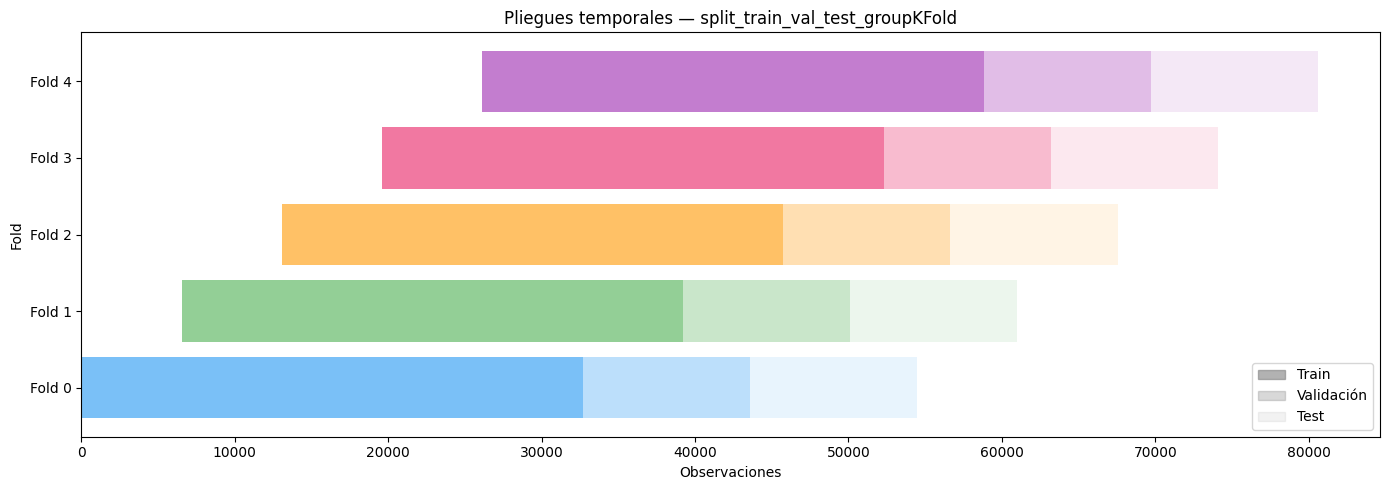

In [42]:
# Visualización de los pliegues
fig, ax = plt.subplots(figsize=(14, 5))

n_total = len(log_return)
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for fold in range(len(X)):
    n_train = X[fold].shape[0]
    n_val   = Xcv[fold].shape[0]
    n_test  = Xtest[fold].shape[0]
    
    # Posición aproximada en la serie completa
    start_train = fold * (n_train // len(X))
    end_train   = start_train + n_train
    end_val     = end_train + n_val
    end_test    = end_val + n_test

    y_pos = fold

    ax.barh(y_pos, n_train, left=start_train,
            color=colores[fold], alpha=0.6, label=f'Fold {fold} Train')
    ax.barh(y_pos, n_val, left=end_train,
            color=colores[fold], alpha=0.3)
    ax.barh(y_pos, n_test, left=end_val,
            color=colores[fold], alpha=0.1)

train_patch = mpatches.Patch(color='gray', alpha=0.6, label='Train')
val_patch   = mpatches.Patch(color='gray', alpha=0.3, label='Validación')
test_patch  = mpatches.Patch(color='gray', alpha=0.1, label='Test')

ax.legend(handles=[train_patch, val_patch, test_patch], loc='lower right')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Fold')
ax.set_title('Pliegues temporales — split_train_val_test_groupKFold')
ax.set_yticks(range(len(X)))
ax.set_yticklabels([f'Fold {i}' for i in range(len(X))])
plt.tight_layout()
plt.show()

## Optimizacion de hiperparametros

Se definen los espacios de búsqueda y los modelos para los 4 métodos de 
optimización. El preprocesamiento (StandardScaler) se aplica dentro de 
cada fold, ajustándose solo con datos de entrenamiento para evitar 
data leakage temporal.

In [43]:
# Métrica de dirección — qué tan bien predice si sube o baja
def direction_accuracy(y_real, y_pred):
    y_real = y_real.ravel()
    y_pred = y_pred.ravel()

    return np.mean(
        np.sign(y_real) == np.sign(y_pred)
    )


# ─────────────────────────────────────────────────────────────────────────────
# Función de evaluación unificada: ML con StandardScaler + ARIMA sin scaler
# El condicional se activa cuando ModelClass == 'ARIMA'
# ─────────────────────────────────────────────────────────────────────────────
def evaluar_params(ModelClass, params, seed=None):
    rmses, maes, das = [], [], []

    for fold in range(len(X)):
        X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
        X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
        y_test_raw  = ytest[fold].reshape(ytest[fold].shape[0], -1).ravel()

        # ── ARIMA: sin scaler, entrena sobre la serie de entrenamiento ────────
        if ModelClass == 'ARIMA':
            try:
                fit = ARIMA(
                    y_train_raw.ravel(),
                    order=(params['p'], params['d'], params['q'])
                ).fit()
                yhat = fit.forecast(steps=len(y_test_raw))
            except Exception:
                yhat = np.zeros(len(y_test_raw))

        # ── Modelos ML: escalado fold-by-fold sin leakage ─────────────────────
        else:
            scaler_x = StandardScaler().fit(X_train_raw)
            scaler_y = StandardScaler().fit(y_train_raw)

            X_train = scaler_x.transform(X_train_raw)
            X_test_ = scaler_x.transform(X_test_raw)
            y_train = scaler_y.transform(y_train_raw).ravel()

            try:
                if seed is not None and 'random_state' in ModelClass().get_params():
                    model = ModelClass(**params, random_state=seed)
                else:
                    model = ModelClass(**params)
            except Exception:
                model = ModelClass(**params)

            model.fit(X_train, y_train)
            yhat = scaler_y.inverse_transform(
                model.predict(X_test_).reshape(-1, 1)
            ).ravel()

        rmses.append(np.sqrt(mean_squared_error(y_test_raw, yhat)))
        maes.append(mean_absolute_error(y_test_raw, yhat))
        das.append(direction_accuracy(y_test_raw, yhat))

    return np.mean(rmses), np.mean(maes), np.mean(das)


# Sentinel 'ARIMA' como clave — los param_grids/random/optuna/deap
# lo detectan por nombre; evaluar_params activa la rama correcta
modelos = {
    'KNN'          : KNeighborsRegressor,
    'Ridge'        : Ridge,
    'Lasso'        : Lasso,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'XGBoost'      : XGBRegressor,
    'SVR'          : LinearSVR,
    'ARIMA'        : 'ARIMA'          # sentinel — usa rama ARIMA en evaluar_params
}

print('Función de evaluación unificada lista (ML + ARIMA)')


Función de evaluación unificada lista (ML + ARIMA)


### Grid search

Grid Search evalúa exhaustivamente todas las combinaciones posibles del 
espacio de hiperparámetros. Es el método más exhaustivo pero también el 
más costoso computacionalmente; el número de evaluaciones crece 
exponencialmente con el número de hiperparámetros.

In [44]:
# p,q ∈ {0..3}, d=0 (log-retornos ya estacionarios)
param_grids = {
    'KNN'          : {'n_neighbors': [3, 5, 7, 10, 15],
                      'weights'    : ['uniform', 'distance']},
    'Ridge'        : {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso'        : {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]},
    'Decision Tree': {'max_depth'        : [3, 5, 7, 10],
                      'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100, 200],
                      'max_depth'   : [3, 5, 7]},
    'XGBoost'      : {'n_estimators' : [50, 100, 200],
                      'learning_rate': [0.01, 0.1, 0.3]},
    'SVR'          : {'C'      : [0.01, 0.1, 1.0, 10.0],
                      'epsilon': [0.0, 0.001, 0.01]},
    'ARIMA'        : {'p': [0, 1, 2, 3], 'd': [0], 'q': [0, 1, 2, 3]}
}

resultados_grid = {}

for nombre, ModelClass in modelos.items():
    t0         = time.time()
    mejor_rmse = np.inf
    mejor_params = {}
    n_iter     = 0
    keys       = list(param_grids[nombre].keys())

    for vals in product(*param_grids[nombre].values()):
        params = dict(zip(keys, vals))
        # ARIMA(0,0,0) es trivial — se omite
        if nombre == 'ARIMA' and params['p'] == 0 and params['q'] == 0:
            continue
        rmse, mae, da = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        n_iter += 1
        if rmse < mejor_rmse:
            mejor_rmse, mejor_mae, mejor_da, mejor_params = rmse, mae, da, params

    resultados_grid[nombre] = {
        'rmse': mejor_rmse, 'mae': mejor_mae, 'da': mejor_da,
        'params': mejor_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': n_iter
    }
    print(f'{nombre:15s} — RMSE: {mejor_rmse:.5f} | MAE: {mejor_mae:.5f} | '
          f'DA: {mejor_da:.3f} | Tiempo: {resultados_grid[nombre]["tiempo"]}s')


KNN             — RMSE: 0.00277 | MAE: 0.00166 | DA: 0.541 | Tiempo: 14.57s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.1s
Lasso           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.07s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.536 | Tiempo: 4.96s
Random Forest   — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.562 | Tiempo: 219.8s
XGBoost         — RMSE: 0.00274 | MAE: 0.00160 | DA: 0.565 | Tiempo: 7.38s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574 | Tiempo: 14.54s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 107.94s


### Random search

Random Search muestrea aleatoriamente combinaciones del espacio de 
hiperparámetros. A diferencia de Grid Search, permite explorar rangos 
continuos y es más eficiente cuando el espacio es grande debido a que con el mismo 
número de evaluaciones cubre más territorio del espacio de búsqueda.

In [45]:
param_random = {
    'KNN'          : {'n_neighbors': randint(2, 20),
                      'weights'    : ['uniform', 'distance']},
    'Ridge'        : {'alpha': uniform(0.0001, 100)},
    'Lasso'        : {'alpha': uniform(0.00001, 1)},
    'Decision Tree': {'max_depth'        : randint(2, 15),
                      'min_samples_split': randint(2, 20)},
    'Random Forest': {'n_estimators': randint(50, 300),
                      'max_depth'   : randint(2, 10)},
    'XGBoost'      : {'n_estimators' : randint(50, 300),
                      'learning_rate': uniform(0.01, 0.3)},
    'SVR'          : {'C'      : uniform(0.01, 20),
                      'epsilon': uniform(0.0,   0.05)},
    'ARIMA'        : {'p': [0, 1, 2, 3, 4], 'd': [0], 'q': [0, 1, 2, 3, 4]}
}

N_ITER_RANDOM = 30
resultados_random = {}
np.random.seed(RANDOM_SEED)

for nombre, ModelClass in modelos.items():
    t0         = time.time()
    mejor_rmse = np.inf
    mejor_params = {}

    for _ in range(N_ITER_RANDOM):
        params = {}
        if nombre == 'ARIMA':
            params = {
                'p': int(np.random.choice(param_random['ARIMA']['p'])),
                'd': 0,
                'q': int(np.random.choice(param_random['ARIMA']['q']))
            }
            if params['p'] == 0 and params['q'] == 0:
                continue
        else:
            for k, v in param_random[nombre].items():
                if hasattr(v, 'rvs'):
                    params[k] = v.rvs()
                    if isinstance(param_random[nombre][k], type(randint(1, 2))):
                        params[k] = int(params[k])
                else:
                    params[k] = np.random.choice(v)

        rmse, mae, da = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        if rmse < mejor_rmse:
            mejor_rmse, mejor_mae, mejor_da, mejor_params = rmse, mae, da, params

    resultados_random[nombre] = {
        'rmse': mejor_rmse, 'mae': mejor_mae, 'da': mejor_da,
        'params': mejor_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': N_ITER_RANDOM
    }
    print(f'{nombre:15s} — RMSE: {mejor_rmse:.5f} | MAE: {mejor_mae:.5f} | '
          f'DA: {mejor_da:.3f} | Tiempo: {resultados_random[nombre]["tiempo"]}s')


KNN             — RMSE: 0.00276 | MAE: 0.00165 | DA: 0.544 | Tiempo: 48.63s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.52s
Lasso           — RMSE: 0.00271 | MAE: 0.00160 | DA: 0.567 | Tiempo: 0.45s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.527 | Tiempo: 16.3s
Random Forest   — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.562 | Tiempo: 1412.33s
XGBoost         — RMSE: 0.00276 | MAE: 0.00161 | DA: 0.566 | Tiempo: 41.29s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.572 | Tiempo: 73.99s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 274.3s


### Bayesiana (Optuna)

La optimización bayesiana usa el historial de evaluaciones anteriores para 
decidir qué hiperparámetros explorar a continuación. Es más eficiente que 
Grid y Random Search porque aprende del pasado y concentra las evaluaciones 
en las regiones más prometedoras del espacio de búsqueda.

KNN             — RMSE: 0.00275 | MAE: 0.00164 | DA: 0.545 | Tiempo: 56.54s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.47s
Lasso           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.42s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.527 | Tiempo: 11.18s
Random Forest   — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.561 | Tiempo: 1434.25s
XGBoost         — RMSE: 0.00274 | MAE: 0.00160 | DA: 0.566 | Tiempo: 26.92s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574 | Tiempo: 43.32s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 375.58s


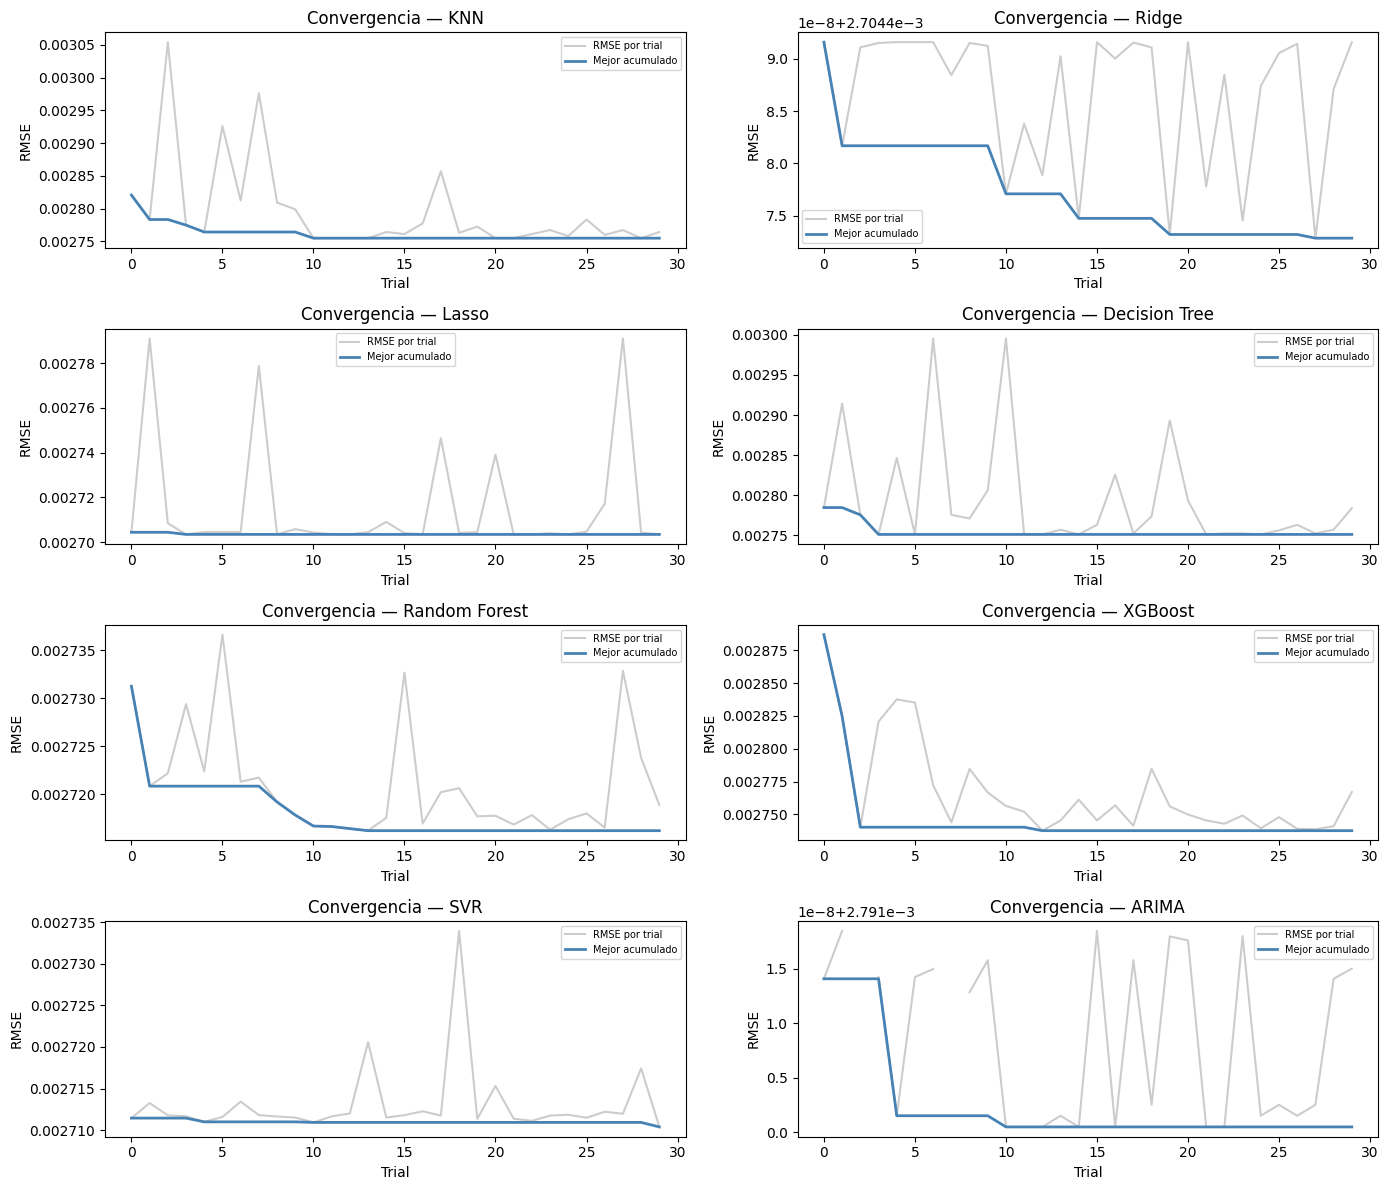

In [49]:
resultados_optuna = {}

for nombre, ModelClass in modelos.items():
    t0 = time.time()

    def objective(trial):
        if nombre == 'ARIMA':
            params = {
                'p': trial.suggest_int('p', 0, 4),
                'd': 0,
                'q': trial.suggest_int('q', 0, 4)
            }
            if params['p'] == 0 and params['q'] == 0:
                return np.inf
        elif nombre == 'KNN':
            params = {
                'n_neighbors': trial.suggest_int('n_neighbors', 2, 20),
                'weights'    : trial.suggest_categorical('weights', ['uniform', 'distance'])
            }
        elif nombre == 'Ridge':
            params = {'alpha': trial.suggest_float('alpha', 0.0001, 100, log=True)}
        elif nombre == 'Lasso':
            params = {'alpha': trial.suggest_float('alpha', 0.00001, 1, log=True)}
        elif nombre == 'Decision Tree':
            params = {
                'max_depth'        : trial.suggest_int('max_depth', 2, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20)
            }
        elif nombre == 'Random Forest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth'   : trial.suggest_int('max_depth', 2, 10)
            }
        elif nombre == 'XGBoost':
            params = {
                'n_estimators' : trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
            }
        else:  # SVR (LinearSVR)
            params = {
                'C'      : trial.suggest_float('C', 0.01, 20, log=True),
                'epsilon': trial.suggest_float('epsilon', 0.001, 0.1, log=True)
            }
        rmse, _, _ = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        return rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=30)

    # ARIMA: best_params de Optuna no incluye 'd' porque no es un trial param
    # se reincorpora aquí para que evaluar_params tenga el dict completo
    best_params = study.best_params
    if nombre == 'ARIMA':
        best_params = {'p': best_params['p'], 'd': 0, 'q': best_params['q']}

    rmse, mae, da = evaluar_params(ModelClass, best_params, seed=RANDOM_SEED)

    resultados_optuna[nombre] = {
        'rmse': rmse, 'mae': mae, 'da': da,
        'params': best_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': 30,
        'history': [t.value for t in study.trials]
    }
    print(f'{nombre:15s} — RMSE: {rmse:.5f} | MAE: {mae:.5f} | '
          f'DA: {da:.3f} | Tiempo: {resultados_optuna[nombre]["tiempo"]}s')

# Gráfica de convergencia — 4 filas x 2 cols para 8 modelos (7 ML + ARIMA)
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, nombre in enumerate(modelos.keys()):
    history  = resultados_optuna[nombre]['history']
    history  = [v if (v is not None and np.isfinite(v)) else np.inf for v in history]
    finite   = [v for v in history if np.isfinite(v)]
    best_acc = np.minimum.accumulate(history) if finite else history
    axes[i].plot(history, alpha=0.4, color='gray', label='RMSE por trial')
    axes[i].plot(best_acc, color='steelblue', linewidth=2, label='Mejor acumulado')
    axes[i].set_title(f'Convergencia — {nombre}')
    axes[i].set_xlabel('Trial')
    axes[i].set_ylabel('RMSE')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

### Genetico (DEAP)

Los algoritmos genéticos simulan el proceso de selección natural para 
encontrar los mejores hiperparámetros. Cada individuo representa una 
combinación de hiperparámetros que se evalúa, selecciona, cruza y muta 
a lo largo de varias generaciones, convergiendo hacia mejores soluciones.

KNN             — RMSE: 0.00305 | MAE: 0.00189 | DA: 0.522 | Tiempo: 28.95s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.45s
Lasso           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 0.38s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.527 | Tiempo: 4.17s
Random Forest   — RMSE: 0.00273 | MAE: 0.00161 | DA: 0.547 | Tiempo: 24.43s
XGBoost         — RMSE: 0.00274 | MAE: 0.00161 | DA: 0.563 | Tiempo: 3.14s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574 | Tiempo: 68.31s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 196.25s


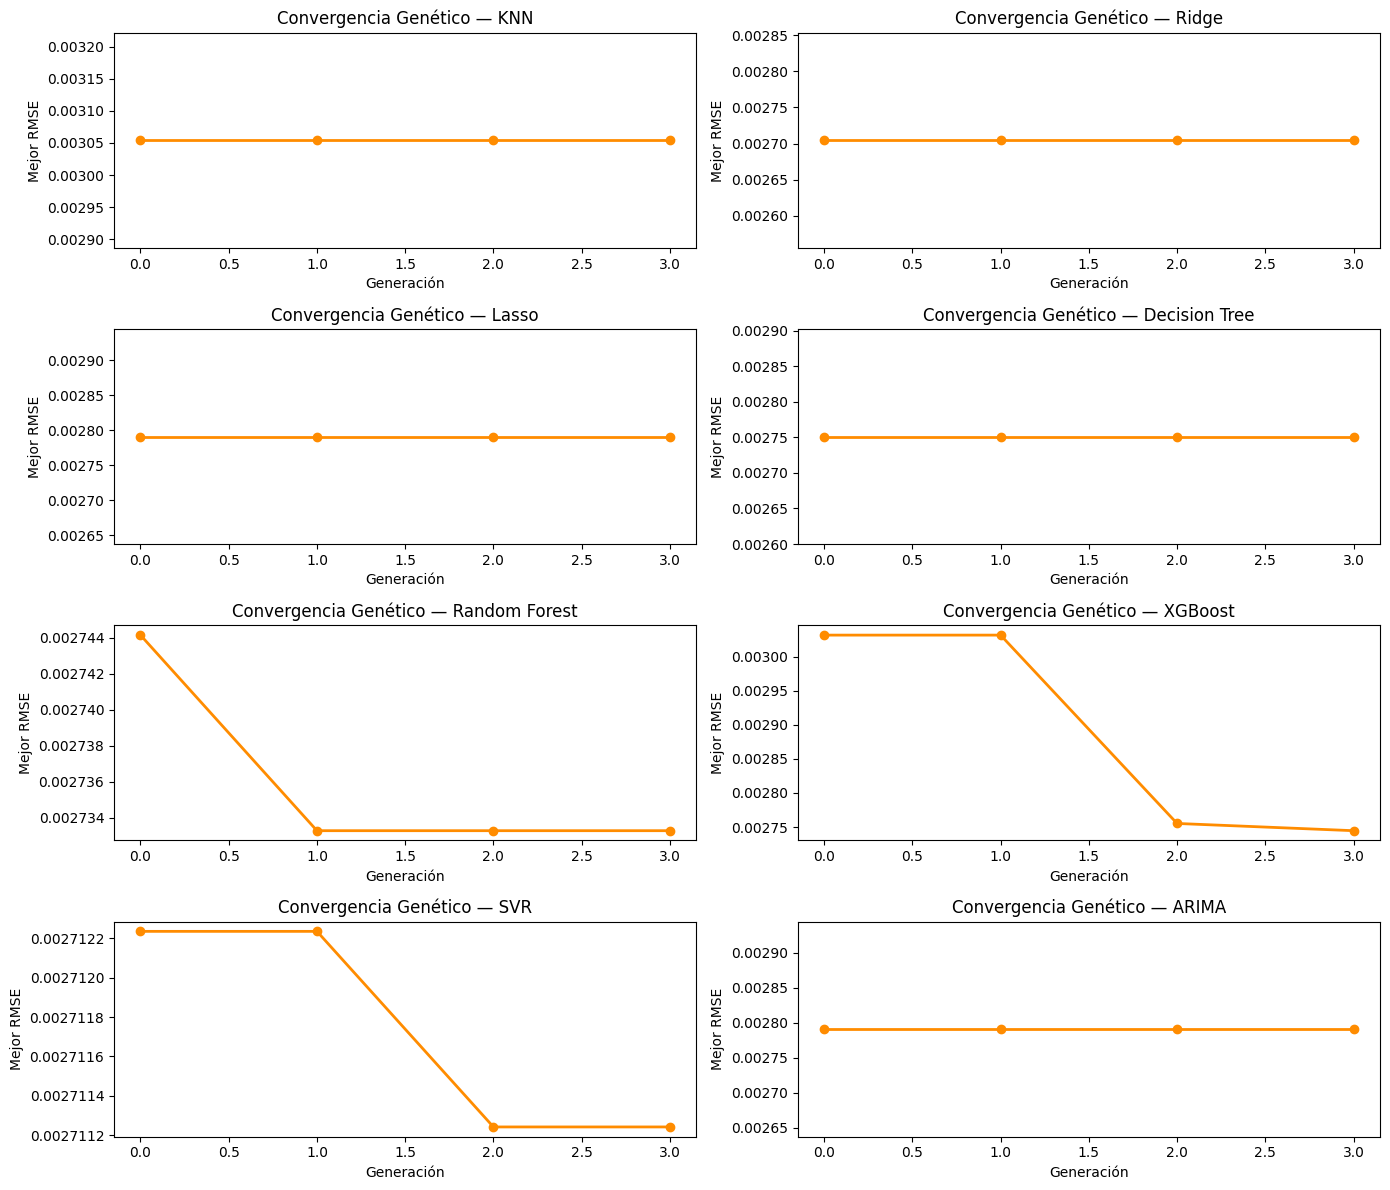

In [51]:
resultados_deap = {}

for nombre, ModelClass in modelos.items():
    t0 = time.time()
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    for attr in ['FitnessMin', 'Individual']:
        if attr in creator.__dict__:
            delattr(creator, attr)

    creator.create('FitnessMin', base.Fitness, weights=(-1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMin)
    toolbox = base.Toolbox()

    def decodificar(individual):
        if nombre == 'ARIMA':
            return {
                'p': max(0, min(4, int(round(abs(individual[0]))))),
                'd': 0,
                'q': max(0, min(4, int(round(abs(individual[1])))))
            }
        elif nombre == 'KNN':
            return {
                'n_neighbors': max(1, int(abs(individual[0]))),
                'weights'    : ['uniform', 'distance'][int(abs(individual[1])) % 2]
            }
        elif nombre in ['Ridge', 'Lasso']:
            return {'alpha': float(10 ** np.clip(individual[0], -5, 2))}
        elif nombre == 'Decision Tree':
            return {
                'max_depth'        : max(1, int(abs(individual[0]))),
                'min_samples_split': max(2, int(abs(individual[1])))
            }
        elif nombre == 'Random Forest':
            return {
                'n_estimators': max(10, int(abs(individual[0]))),
                'max_depth'   : max(1, int(abs(individual[1])))
            }
        elif nombre == 'XGBoost':
            return {
                'n_estimators' : max(10, int(abs(individual[0]))),
                'learning_rate': float(10 ** np.clip(individual[1], -2, 0))
            }
        else:  # SVR (LinearSVR)
            return {
                'C'      : float(10 ** np.clip(individual[0], -2, 2)),
                'epsilon': float(10 ** np.clip(individual[1], -3, -1))
            }

    def evaluar(individual):
        try:
            params = decodificar(individual)
            if nombre == 'ARIMA' and params['p'] == 0 and params['q'] == 0:
                return (999,)
            rmse, _, _ = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
            return (rmse,)
        except Exception:
            return (999,)

    n_genes = 1 if nombre in ['Ridge', 'Lasso'] else 2
    toolbox.register('attr_float', random.uniform, 0, 4)
    toolbox.register('individual', tools.initRepeat,
                     creator.Individual, toolbox.attr_float, n=n_genes)
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluar)
    toolbox.register('mate',   tools.cxBlend, alpha=0.5)
    toolbox.register('mutate', tools.mutGaussian, mu=0, sigma=1, indpb=0.3)
    toolbox.register('select', tools.selTournament, tournsize=3)

    pop   = toolbox.population(n=10)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(
        lambda ind: ind.fitness.values[0] if ind.fitness.valid else 999
    )
    stats.register('min', np.min)

    pop, log = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.3,
        ngen=3, stats=stats, halloffame=hof, verbose=False
    )

    best_params = decodificar(hof[0])
    rmse, mae, da = evaluar_params(ModelClass, best_params, seed=RANDOM_SEED)

    resultados_deap[nombre] = {
        'rmse': rmse, 'mae': mae, 'da': da,
        'params': best_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': 30,
        'history': [gen['min'] for gen in log]
    }
    print(f'{nombre:15s} — RMSE: {rmse:.5f} | MAE: {mae:.5f} | '
          f'DA: {da:.3f} | Tiempo: {resultados_deap[nombre]["tiempo"]}s')

# Gráfica convergencia genético — 4x2 para 8 modelos
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, nombre in enumerate(modelos.keys()):
    axes[i].plot(resultados_deap[nombre]['history'],
                 marker='o', color='darkorange', linewidth=2)
    axes[i].set_title(f'Convergencia Genético — {nombre}')
    axes[i].set_xlabel('Generación')
    axes[i].set_ylabel('Mejor RMSE')

plt.tight_layout()
plt.show()


### Tabla comparativa final

Comparación de los cuatro métodos de optimización por modelo, evaluando 
RMSE, MAE, Direction Accuracy, tiempo de ejecución e iteraciones.

In [56]:
filas = []
for nombre in modelos.keys():
    for metodo, resultados in [('Grid Search',  resultados_grid),
                                ('Random Search', resultados_random),
                                ('Bayesiana',     resultados_optuna),
                                ('Genético',      resultados_deap)]:
        filas.append({
            'Modelo'     : nombre,
            'Método'     : metodo,
            'RMSE'       : round(resultados[nombre]['rmse'], 5),
            'MAE'        : round(resultados[nombre]['mae'], 5),
            'DA'         : round(resultados[nombre]['da'], 3),
            'Tiempo (s)' : resultados[nombre]['tiempo'],
            'Iteraciones': resultados[nombre]['iteraciones']
        })

tabla = pd.DataFrame(filas)

# Highlight mejor RMSE por modelo
def highlight_best(df):
    styled = df.style\
        .background_gradient(subset=['RMSE'], cmap='RdYlGn_r')\
        .background_gradient(subset=['DA'],   cmap='RdYlGn')\
        .background_gradient(subset=['MAE'],  cmap='RdYlGn_r')\
        .format({
            'RMSE'      : '{:.5f}',
            'MAE'       : '{:.5f}',
            'DA'        : '{:.3f}',
            'Tiempo (s)': '{:.2f}'
        })\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#f0f4f8')]},
        ])\
        .hide(axis='index')
    return styled

highlight_best(tabla)

Modelo,Método,RMSE,MAE,DA,Tiempo (s),Iteraciones
KNN,Grid Search,0.00277,0.00166,0.541,14.57,10
KNN,Random Search,0.00276,0.00165,0.544,48.63,30
KNN,Bayesiana,0.00275,0.00164,0.545,56.54,30
KNN,Genético,0.00305,0.00189,0.522,28.95,30
Ridge,Grid Search,0.00270,0.00160,0.569,0.10,6
Ridge,Random Search,0.00270,0.00160,0.569,0.52,30
Ridge,Bayesiana,0.00270,0.00160,0.569,0.47,30
Ridge,Genético,0.00270,0.00160,0.569,0.45,30
Lasso,Grid Search,0.00270,0.00160,0.569,0.07,5
Lasso,Random Search,0.00271,0.00160,0.567,0.45,30


## Analisis de residuos

Se analizan los residuos del mejor modelo general. Un buen modelo debe 
dejar residuos sin patrón, independientes y sin autocorrelación. Se 
aplican el test de Ljung-Box para detectar autocorrelación lineal y el 
test BDS para dependencia no lineal.

Mejor modelo: Lasso con Optuna — RMSE: 0.00270

Ljung-Box p-valor: 0.0098 — Autocorrelación detectada ❌
BDS p-valor:       0.0000 — Dependencia no lineal ❌


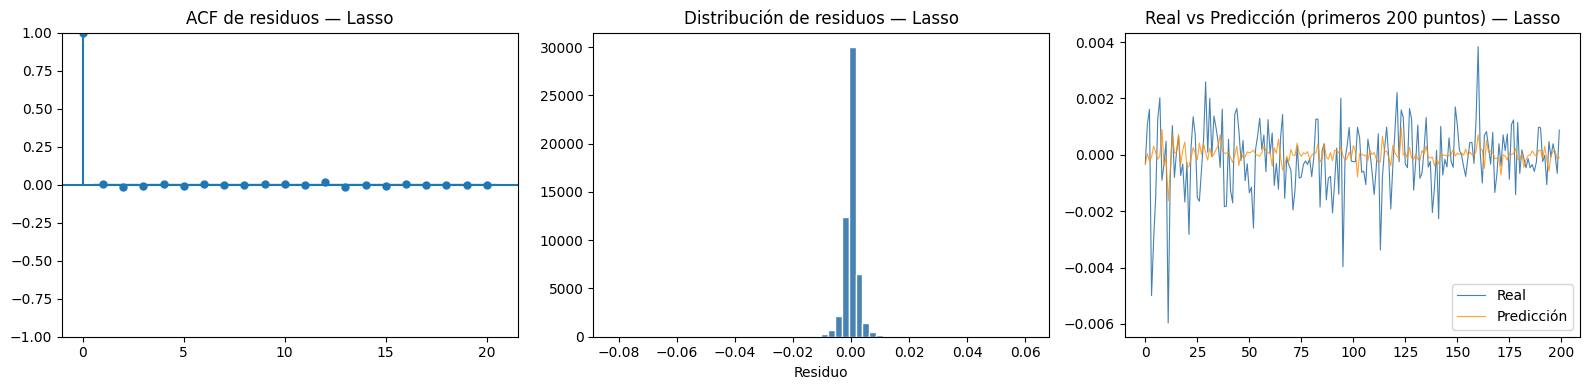

In [57]:
# Identificar mejor modelo global (incluyendo ARIMA)
mejor_global = min(
    [(nombre, metodo, res[nombre]['rmse'])
     for nombre in modelos.keys()
     for metodo, res in [('Grid',   resultados_grid),
                         ('Random', resultados_random),
                         ('Optuna', resultados_optuna),
                         ('DEAP',   resultados_deap)]],
    key=lambda x: x[2]
)
print(f'Mejor modelo: {mejor_global[0]} con {mejor_global[1]} — RMSE: {mejor_global[2]:.5f}')

nombre_mejor = mejor_global[0]
ModelClass   = modelos[nombre_mejor]

if mejor_global[1] == 'Grid':
    params = resultados_grid[nombre_mejor]['params']
elif mejor_global[1] == 'Random':
    params = resultados_random[nombre_mejor]['params']
elif mejor_global[1] == 'Optuna':
    params = resultados_optuna[nombre_mejor]['params']
else:
    params = resultados_deap[nombre_mejor]['params']

# ─────────────────────────────────────────────────────────────────────────────
# Reentrenar fold-by-fold y recolectar residuos
# ─────────────────────────────────────────────────────────────────────────────
residuos_todos, preds_todos, real_todos = [], [], []
modelo_ultimo = None   # guardamos el modelo del último fold para exportar

for fold in range(len(X)):
    X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
    y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
    y_test_raw  = ytest[fold].ravel()

    if nombre_mejor == 'ARIMA':
        fit = ARIMA(y_train_raw.ravel(),
                    order=(params['p'], params['d'], params['q'])).fit()
        yhat = fit.forecast(steps=len(y_test_raw))
        modelo_ultimo = fit   # ARIMAResults es serializable con joblib
    else:
        scaler_x = StandardScaler().fit(X_train_raw)
        scaler_y = StandardScaler().fit(y_train_raw)
        X_train  = scaler_x.transform(X_train_raw)
        X_test_  = scaler_x.transform(X_test_raw)
        y_train  = scaler_y.transform(y_train_raw).ravel()

        try:
            model = ModelClass(**params, random_state=RANDOM_SEED)
        except Exception:
            model = ModelClass(**params)

        model.fit(X_train, y_train)
        yhat = scaler_y.inverse_transform(
            model.predict(X_test_).reshape(-1, 1)
        ).ravel()

        # guardamos el modelo + scalers del último fold para exportar
        modelo_ultimo = {
            'model'   : model,
            'scaler_x': scaler_x,
            'scaler_y': scaler_y,
            'params'  : params,
            'nombre'  : nombre_mejor
        }

    residuos_todos.extend(y_test_raw - yhat)
    preds_todos.extend(yhat)
    real_todos.extend(y_test_raw)

residuos = np.array(residuos_todos)
preds    = np.array(preds_todos)
real     = np.array(real_todos)

# ─────────────────────────────────────────────────────────────────────────────
# Exportar modelo entrenado como .pkl
# ─────────────────────────────────────────────────────────────────────────────
pkl_path = f'outputs/mejor_modelobenchmark_{nombre_mejor.replace(" ", "_")}.pkl'
joblib.dump(modelo_ultimo, pkl_path)

# ─────────────────────────────────────────────────────────────────────────────
# Tests estadísticos
# ─────────────────────────────────────────────────────────────────────────────
lb    = acorr_ljungbox(residuos, lags=[10], return_df=True)
lb_p  = lb['lb_pvalue'].values[0]
bds_r = bds(residuos[:2000], max_dim=2)
bds_p = bds_r[1].item()

print(f'\nLjung-Box p-valor: {lb_p:.4f} — '
      f'{"Residuos independientes ✅" if lb_p > 0.05 else "Autocorrelación detectada ❌"}')
print(f'BDS p-valor:       {bds_p:.4f} — '
      f'{"Sin dependencia no lineal ✅" if bds_p > 0.05 else "Dependencia no lineal ❌"}')

# Gráficas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_acf(residuos, lags=20, ax=axes[0], alpha=0.05)
axes[0].set_title(f'ACF de residuos — {nombre_mejor}')

axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='white')
axes[1].set_title(f'Distribución de residuos — {nombre_mejor}')
axes[1].set_xlabel('Residuo')

axes[2].plot(real[:200],  label='Real',       color='steelblue',  linewidth=0.8)
axes[2].plot(preds[:200], label='Predicción', color='darkorange', linewidth=0.8, alpha=0.8)
axes[2].set_title(f'Real vs Predicción (primeros 200 puntos) — {nombre_mejor}')
axes[2].legend()

plt.tight_layout()
plt.show()


### Booststrap IC 95%

Bootstrap estima intervalos de confianza para RMSE, MAE y Direction 
Accuracy sin asumir distribución normal de los errores, remuestreando 
los datos 1000 veces con reemplazo.

In [65]:

def bootstrap_ic(real, preds, n_boot=1000, seed=42, block_size=20):
    np.random.seed(seed)
    n = len(real)
    n_blocks = int(np.ceil(n / block_size))
    rmses, maes, das = [], [], []

    for _ in range(n_boot):
        block_starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, min(s + block_size, n))
                              for s in block_starts])[:n]
        rmses.append(np.sqrt(mean_squared_error(real[idx], preds[idx])))
        maes.append(mean_absolute_error(real[idx], preds[idx]))
        das.append(direction_accuracy(real[idx], preds[idx]))

    return {
        'RMSE': (round(np.percentile(rmses, 2.5), 5),
                 round(np.percentile(rmses, 97.5), 5)),
        'MAE' : (round(np.percentile(maes, 2.5), 5),
                 round(np.percentile(maes, 97.5), 5)),
        'DA'  : (round(np.percentile(das, 2.5), 3),
                 round(np.percentile(das, 97.5), 3))
    }

filas_boot = []

for nombre, ModelClass in modelos.items():
    params = resultados_optuna[nombre]['params']
    preds_boot, real_boot = [], []

    for fold in range(len(X)):
        X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
        X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
        y_test_raw  = ytest[fold].ravel()

        if nombre == 'ARIMA':
            try:
                fit  = ARIMA(y_train_raw.ravel(),
                             order=(params['p'], params['d'], params['q'])).fit()
                yhat = fit.forecast(steps=len(y_test_raw))
            except Exception:
                yhat = np.zeros(len(y_test_raw))
        else:
            scaler_x = StandardScaler().fit(X_train_raw)
            scaler_y = StandardScaler().fit(y_train_raw)
            X_train  = scaler_x.transform(X_train_raw)
            X_test_  = scaler_x.transform(X_test_raw)
            y_train  = scaler_y.transform(y_train_raw).ravel()

            try:
                model = ModelClass(**params, random_state=RANDOM_SEED)
            except Exception:
                model = ModelClass(**params)

            model.fit(X_train, y_train)
            yhat = scaler_y.inverse_transform(
                model.predict(X_test_).reshape(-1, 1)
            ).ravel()

        preds_boot.extend(yhat)
        real_boot.extend(y_test_raw)

    ic = bootstrap_ic(np.array(real_boot), np.array(preds_boot))
    filas_boot.append({
        'Modelo'      : nombre,
        'IC 95% RMSE' : f"[{ic['RMSE'][0]}, {ic['RMSE'][1]}]",
        'IC 95% MAE'  : f"[{ic['MAE'][0]}, {ic['MAE'][1]}]",
        'IC 95% DA'   : f"[{ic['DA'][0]}, {ic['DA'][1]}]",
        'RMSE_lo'     : ic['RMSE'][0],
        'RMSE_hi'     : ic['RMSE'][1],
        'MAE_lo'      : ic['MAE'][0],
        'MAE_hi'      : ic['MAE'][1],
        'DA_lo'       : ic['DA'][0],
        'DA_hi'       : ic['DA'][1],
    })

df_boot = pd.DataFrame(filas_boot)

def highlight_boot(df):
    return df[['Modelo', 'IC 95% RMSE', 'IC 95% MAE', 'IC 95% DA']].style\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', "#293138")]},
        ])\
        .hide(axis='index')

highlight_boot(df_boot)

csv_boot_path = 'outputs/bootstrap_metricas.csv'
df_boot.to_csv(csv_boot_path, index=False)

display(highlight_boot(df_boot))

Modelo,IC 95% RMSE,IC 95% MAE,IC 95% DA
KNN,"[0.00265, 0.00287]","[0.0016, 0.00168]","[0.541, 0.549]"
Ridge,"[0.0026, 0.00281]","[0.00156, 0.00163]","[0.565, 0.573]"
Lasso,"[0.0026, 0.00281]","[0.00156, 0.00163]","[0.565, 0.573]"
Decision Tree,"[0.00265, 0.00286]","[0.00159, 0.00166]","[0.523, 0.531]"
Random Forest,"[0.00261, 0.00282]","[0.00157, 0.00164]","[0.557, 0.566]"
XGBoost,"[0.00263, 0.00285]","[0.00157, 0.00164]","[0.561, 0.57]"
SVR,"[0.0026, 0.00282]","[0.00156, 0.00163]","[0.57, 0.578]"
ARIMA,"[0.00268, 0.00291]","[0.00159, 0.00167]","[0.502, 0.51]"


## Interpretabilidad — LIME

LIME (Local Interpretable Model-agnostic Explanations) aproxima localmente el comportamiento del modelo con un modelo lineal simple, permitiendo identificar qué features (lags) influyen más en cada predicción individual.

Se aplica únicamente al mejor modelo ML (si el mejor es ARIMA, se usa el segundo mejor ML). Las importancias promedio por feature se exportan a `outputs/lime_metricas.csv` para análisis posterior.

Modelo para LIME: Lasso (Optuna) — RMSE: 0.00270

Importancia media absoluta (LIME, n=200):
lag_7    0.001215
lag_6    0.000159
lag_4    0.000075
lag_3    0.000064
lag_2    0.000032
lag_1    0.000022
lag_5    0.000014


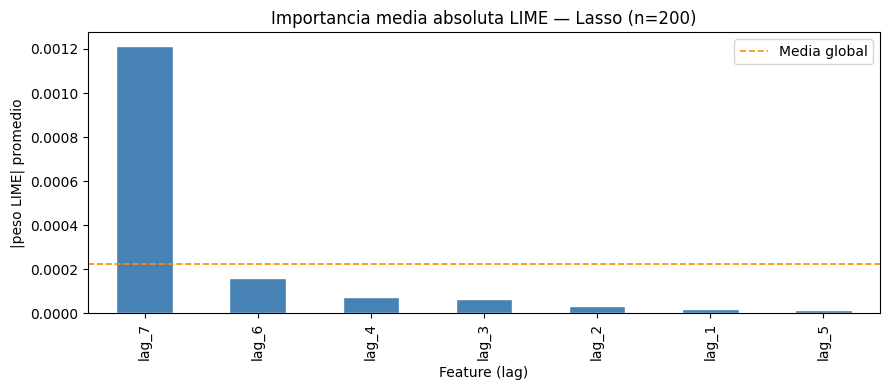

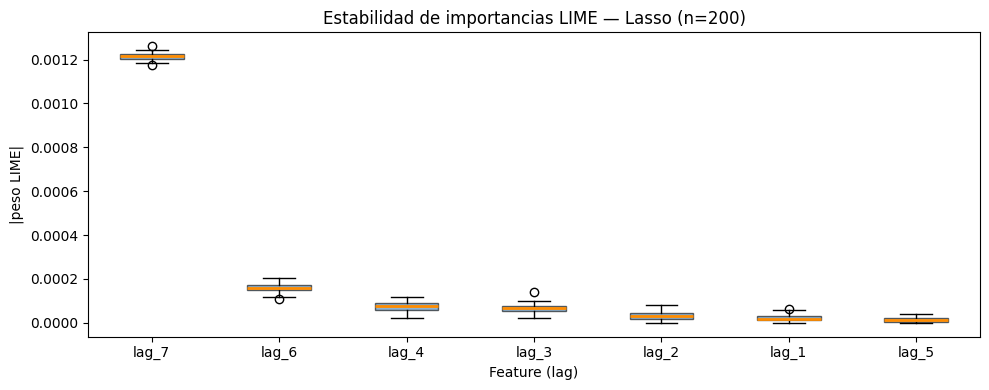

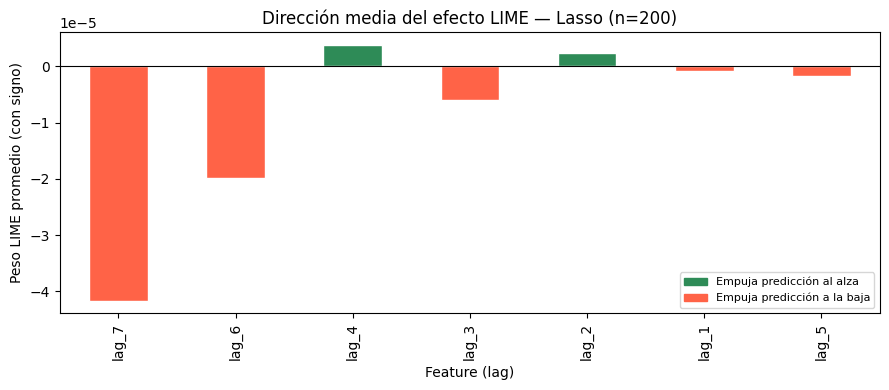

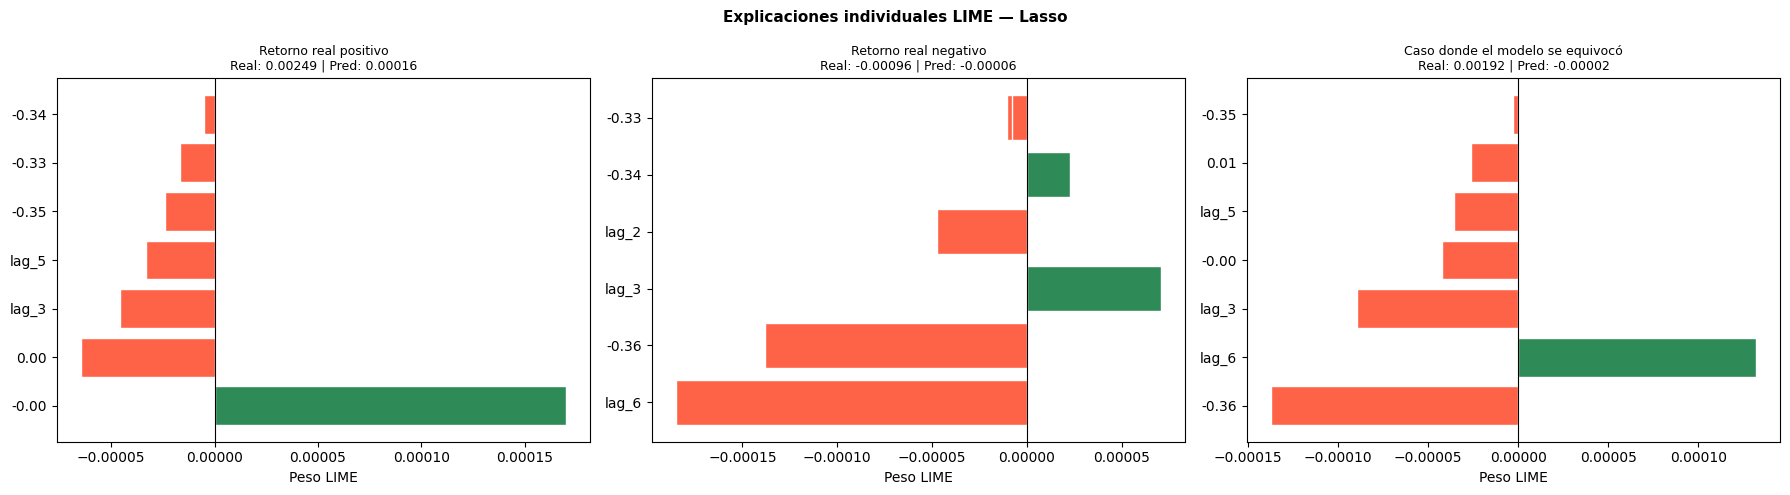


Métricas LIME exportadas → outputs/lime_metricas.csv


In [67]:
from IPython.display import display

# Identificar mejor modelo ML (excluye ARIMA porque no usa features tabulares)
modelos_ml = {k: v for k, v in modelos.items() if k != 'ARIMA'}

mejor_ml = min(
    [(nombre, metodo, res[nombre]['rmse'])
     for nombre in modelos_ml.keys()
     for metodo, res in [('Grid',   resultados_grid),
                         ('Random', resultados_random),
                         ('Optuna', resultados_optuna),
                         ('DEAP',   resultados_deap)]],
    key=lambda x: x[2]
)
nombre_lime     = mejor_ml[0]
ModelClass_lime = modelos_ml[nombre_lime]

if mejor_ml[1] == 'Grid':
    params_lime = resultados_grid[nombre_lime]['params']
elif mejor_ml[1] == 'Random':
    params_lime = resultados_random[nombre_lime]['params']
elif mejor_ml[1] == 'Optuna':
    params_lime = resultados_optuna[nombre_lime]['params']
else:
    params_lime = resultados_deap[nombre_lime]['params']

print(f'Modelo para LIME: {nombre_lime} ({mejor_ml[1]}) — RMSE: {mejor_ml[2]:.5f}')

# Entrenar sobre el último fold
fold_lime   = len(X) - 1
X_train_raw = X[fold_lime].reshape(X[fold_lime].shape[0], -1)
X_test_raw  = Xtest[fold_lime].reshape(Xtest[fold_lime].shape[0], -1)
y_train_raw = y[fold_lime].reshape(y[fold_lime].shape[0], -1)
y_test_raw  = ytest[fold_lime].ravel()

scaler_x_lime = StandardScaler().fit(X_train_raw)
scaler_y_lime = StandardScaler().fit(y_train_raw)

X_train_lime = scaler_x_lime.transform(X_train_raw)
X_test_lime  = scaler_x_lime.transform(X_test_raw)
y_train_lime = scaler_y_lime.transform(y_train_raw).ravel()

try:
    model_lime = ModelClass_lime(**params_lime, random_state=RANDOM_SEED)
except Exception:
    model_lime = ModelClass_lime(**params_lime)

model_lime.fit(X_train_lime, y_train_lime)

feature_names = [f'lag_{i+1}' for i in range(X_train_lime.shape[1])]

def predict_fn(X_scaled):
    return scaler_y_lime.inverse_transform(
        model_lime.predict(X_scaled).reshape(-1, 1)
    ).ravel()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_lime,
    feature_names = feature_names,
    mode          = 'regression',
    random_state  = RANDOM_SEED
)

# ─────────────────────────────────────────────────────────────────────────────
# Importancia media + signo
# ─────────────────────────────────────────────────────────────────────────────
N_LIME = min(200, X_test_lime.shape[0])

importancias_abs = {f: [] for f in feature_names}
importancias_raw = {f: [] for f in feature_names}   # con signo

for i in range(N_LIME):
    exp = explainer.explain_instance(
        X_test_lime[i], predict_fn, num_features=len(feature_names)
    )
    for feat, weight in exp.as_list():
        feat_name = feat.split(' ')[0].split('>')[0].split('<')[0].strip()
        if feat_name in importancias_abs:
            importancias_abs[feat_name].append(abs(weight))
            importancias_raw[feat_name].append(weight)

imp_media = pd.Series(
    {f: np.mean(v) if v else 0.0 for f, v in importancias_abs.items()}
).sort_values(ascending=False)

imp_signed = pd.Series(
    {f: np.mean(v) if v else 0.0 for f, v in importancias_raw.items()}
)

print(f'\nImportancia media absoluta (LIME, n={N_LIME}):')
print(imp_media.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# Figura 1 — Importancia media absoluta (barras)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
imp_media.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Importancia media absoluta LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('|peso LIME| promedio')
ax.axhline(imp_media.mean(), color='darkorange', linestyle='--',
           linewidth=1.2, label='Media global')
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 2 — Distribución de pesos por lag (boxplot — estabilidad)
# ─────────────────────────────────────────────────────────────────────────────
data_box = [importancias_abs[f] for f in imp_media.index]

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='darkorange', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_xticklabels(imp_media.index, rotation=0)
ax.set_title(f'Estabilidad de importancias LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('|peso LIME|')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 3 — Dirección media del efecto por lag (signed weights)
# ─────────────────────────────────────────────────────────────────────────────
imp_signed_sorted = imp_signed[imp_media.index]
colors = ['seagreen' if v >= 0 else 'tomato' for v in imp_signed_sorted]

fig, ax = plt.subplots(figsize=(9, 4))
imp_signed_sorted.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Dirección media del efecto LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('Peso LIME promedio (con signo)')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='seagreen', label='Empuja predicción al alza'),
    plt.Rectangle((0,0),1,1, color='tomato',   label='Empuja predicción a la baja')
], fontsize=8)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 4 — Explicaciones individuales: 3 casos concretos
# caso positivo real, caso negativo real, caso donde el modelo se equivocó
# ─────────────────────────────────────────────────────────────────────────────
preds_test = predict_fn(X_test_lime)

# Índices de los 3 casos
idx_pos   = np.where(y_test_raw > 0)[0][0]          # retorno real positivo
idx_neg   = np.where(y_test_raw < 0)[0][0]          # retorno real negativo
# equivocado: signo predicho ≠ signo real
wrong_mask = np.sign(preds_test) != np.sign(y_test_raw)
idx_wrong  = np.where(wrong_mask)[0][0] if wrong_mask.any() else idx_pos

casos = [
    (idx_pos,   'Retorno real positivo'),
    (idx_neg,   'Retorno real negativo'),
    (idx_wrong, 'Caso donde el modelo se equivocó'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (idx, titulo) in zip(axes, casos):
    exp_caso = explainer.explain_instance(
        X_test_lime[idx], predict_fn, num_features=len(feature_names)
    )
    vals  = exp_caso.as_list()
    feats = [v[0].split(' ')[0].split('>')[0].split('<')[0].strip() for v in vals]
    pesos = [v[1] for v in vals]
    colores_caso = ['seagreen' if p >= 0 else 'tomato' for p in pesos]

    ax.barh(feats, pesos, color=colores_caso, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f'{titulo}\nReal: {y_test_raw[idx]:.5f} | Pred: {preds_test[idx]:.5f}',
        fontsize=9
    )
    ax.set_xlabel('Peso LIME')

plt.suptitle(f'Explicaciones individuales LIME — {nombre_lime}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Exportar métricas LIME como CSV
# ─────────────────────────────────────────────────────────────────────────────
df_lime = pd.DataFrame({
    'feature'           : imp_media.index,
    'importancia_media' : imp_media.values,
    'peso_signed'       : imp_signed[imp_media.index].values,
    'modelo'            : nombre_lime,
    'metodo_optimo'     : mejor_ml[1],
    'n_instancias'      : N_LIME
})
lime_csv_path = 'outputs/lime_metricas.csv'
df_lime.to_csv(lime_csv_path, index=False)
print(f'\nMétricas LIME exportadas → {lime_csv_path}')